<a href="https://colab.research.google.com/github/CalculatedContent/xgbwwdata/blob/main/AnalyzeLongRun.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import json
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Read training logs from the checkpoint notebook outputs
checkpoint_notebook = Path("XGBWW_OpenML_1049_W7W8_Alpha_Checkpoint.ipynb")
if not checkpoint_notebook.exists():
    raise FileNotFoundError(f"Checkpoint notebook not found: {checkpoint_notebook}")

checkpoint_nb = json.loads(checkpoint_notebook.read_text())
output_chunks = []
for cell in checkpoint_nb.get("cells", []):
    for output in cell.get("outputs", []):
        if "text" in output:
            text = output["text"]
            output_chunks.append("".join(text) if isinstance(text, list) else text)

raw_text = "\n".join(output_chunks)
if "round=" not in raw_text:
    raise ValueError(
        "No training log lines found in checkpoint notebook outputs. "
        "Run the checkpoint notebook first so it writes round logs into the saved .ipynb output."
    )


   round  alpha_w7  alpha_w8  test_acc  logloss  alpha_gap  alpha_mean  \
0   4761     2.358     2.230    0.9247   0.2627      0.128      2.2940   
1   4762     2.350     2.268    0.9247   0.2628      0.082      2.3090   
2   4763     2.406     2.390    0.9247   0.2628      0.016      2.3980   
3   4764     2.073     2.416    0.9247   0.2628     -0.343      2.2445   
4   4765     2.348     2.385    0.9247   0.2628     -0.037      2.3665   

   alpha_min  alpha_max  test_acc_roll  logloss_roll  alpha_w7_roll  \
0      2.230      2.358         0.9247      0.262700       2.358000   
1      2.268      2.350         0.9247      0.262750       2.354000   
2      2.390      2.406         0.9247      0.262767       2.371333   
3      2.073      2.416         0.9247      0.262775       2.296750   
4      2.348      2.385         0.9247      0.262780       2.307000   

   alpha_w8_roll  
0         2.2300  
1         2.2490  
2         2.2960  
3         2.3260  
4         2.3378  

Parsed 1380 r

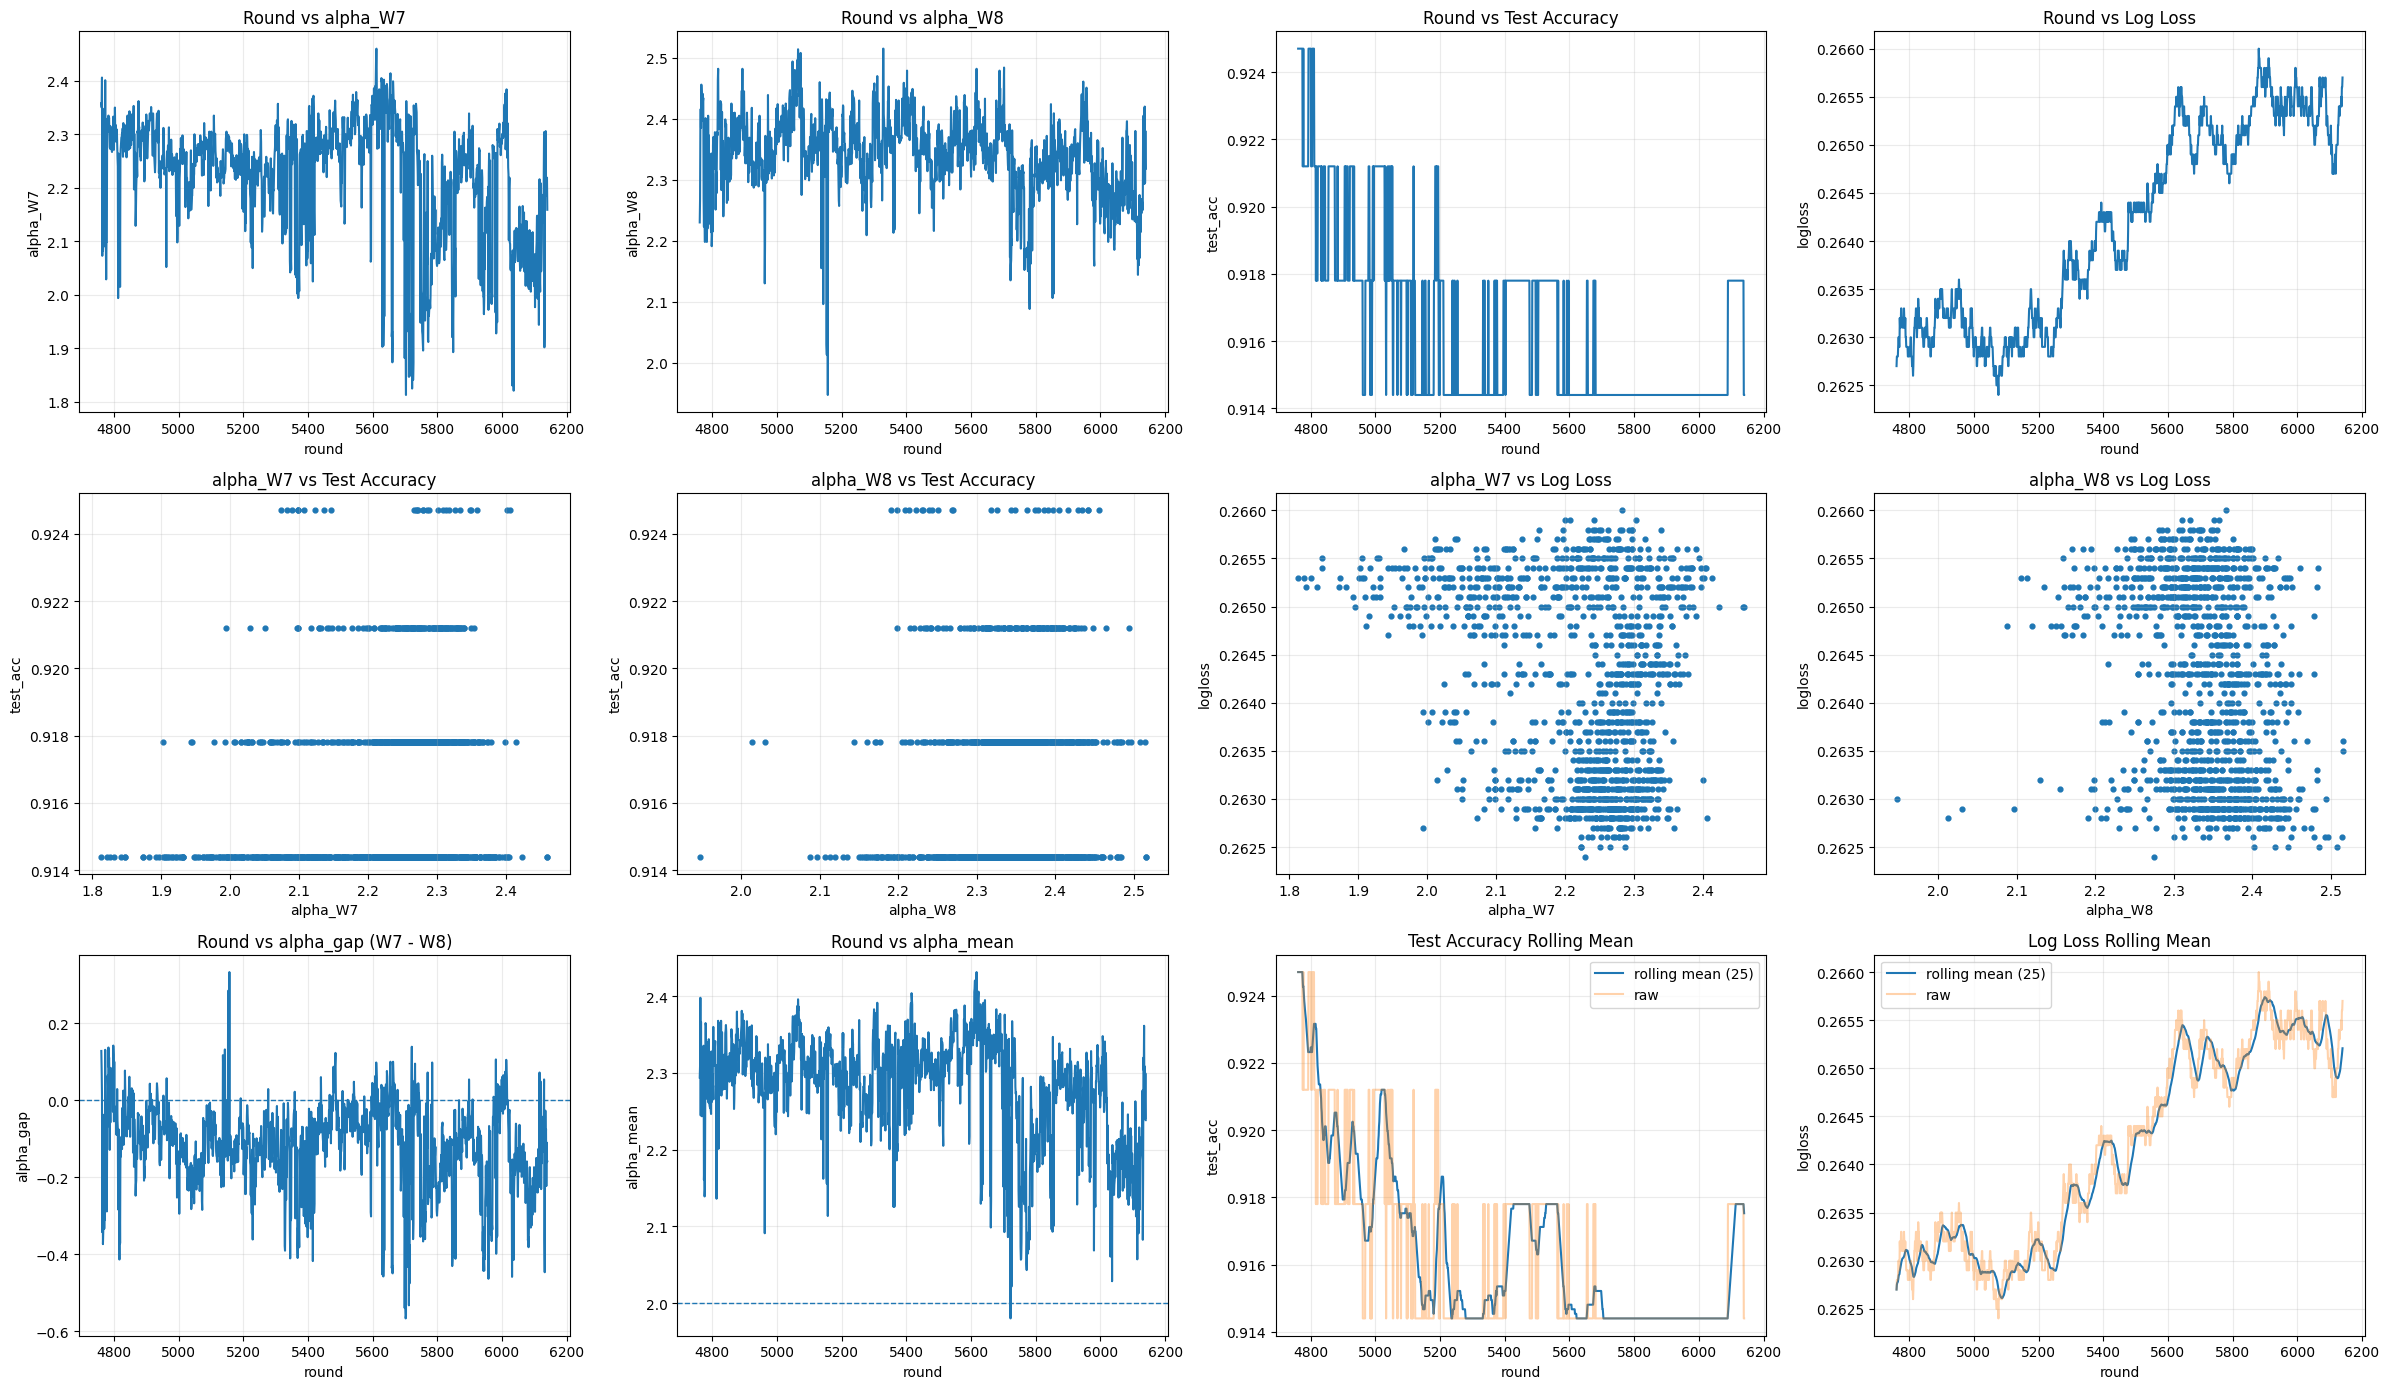

In [3]:

# Regex to parse each line
pattern = re.compile(
    r"round=\s*(?P<round>\d+)\s*\|\s*"
    r"alpha\(W7\)=(?P<alpha_w7>[0-9.]+)\s+"
    r"alpha\(W8\)=(?P<alpha_w8>[0-9.]+)\s*\|\s*"
    r"test_acc=(?P<test_acc>[0-9.]+)\s+"
    r"logloss=(?P<logloss>[0-9.]+)"
)

rows = []
for line in raw_text.splitlines():
    m = pattern.search(line)
    if m:
        rows.append({
            "round": int(m.group("round")),
            "alpha_w7": float(m.group("alpha_w7")),
            "alpha_w8": float(m.group("alpha_w8")),
            "test_acc": float(m.group("test_acc")),
            "logloss": float(m.group("logloss")),
        })

if not rows:
    raise ValueError("No training rows were parsed. Check the raw text format.")

df = pd.DataFrame(rows).sort_values("round").reset_index(drop=True)

# Derived columns
df["alpha_gap"] = df["alpha_w7"] - df["alpha_w8"]
df["alpha_mean"] = (df["alpha_w7"] + df["alpha_w8"]) / 2.0
df["alpha_min"] = df[["alpha_w7", "alpha_w8"]].min(axis=1)
df["alpha_max"] = df[["alpha_w7", "alpha_w8"]].max(axis=1)

# Rolling stats
window = max(5, min(25, len(df) // 20 if len(df) >= 20 else 5))
df["test_acc_roll"] = df["test_acc"].rolling(window=window, min_periods=1).mean()
df["logloss_roll"] = df["logloss"].rolling(window=window, min_periods=1).mean()
df["alpha_w7_roll"] = df["alpha_w7"].rolling(window=window, min_periods=1).mean()
df["alpha_w8_roll"] = df["alpha_w8"].rolling(window=window, min_periods=1).mean()

print(df.head())
print(f"\nParsed {len(df)} rows")
print(f"Rolling window = {window}")

# Make a 12-chart figure
fig, axes = plt.subplots(3, 4, figsize=(24, 14))
axes = axes.ravel()

# 1
axes[0].plot(df["round"], df["alpha_w7"])
axes[0].set_title("Round vs alpha_W7")
axes[0].set_xlabel("round")
axes[0].set_ylabel("alpha_W7")

# 2
axes[1].plot(df["round"], df["alpha_w8"])
axes[1].set_title("Round vs alpha_W8")
axes[1].set_xlabel("round")
axes[1].set_ylabel("alpha_W8")

# 3
axes[2].plot(df["round"], df["test_acc"])
axes[2].set_title("Round vs Test Accuracy")
axes[2].set_xlabel("round")
axes[2].set_ylabel("test_acc")

# 4
axes[3].plot(df["round"], df["logloss"])
axes[3].set_title("Round vs Log Loss")
axes[3].set_xlabel("round")
axes[3].set_ylabel("logloss")

# 5
axes[4].scatter(df["alpha_w7"], df["test_acc"], s=12)
axes[4].set_title("alpha_W7 vs Test Accuracy")
axes[4].set_xlabel("alpha_W7")
axes[4].set_ylabel("test_acc")

# 6
axes[5].scatter(df["alpha_w8"], df["test_acc"], s=12)
axes[5].set_title("alpha_W8 vs Test Accuracy")
axes[5].set_xlabel("alpha_W8")
axes[5].set_ylabel("test_acc")

# 7
axes[6].scatter(df["alpha_w7"], df["logloss"], s=12)
axes[6].set_title("alpha_W7 vs Log Loss")
axes[6].set_xlabel("alpha_W7")
axes[6].set_ylabel("logloss")

# 8
axes[7].scatter(df["alpha_w8"], df["logloss"], s=12)
axes[7].set_title("alpha_W8 vs Log Loss")
axes[7].set_xlabel("alpha_W8")
axes[7].set_ylabel("logloss")

# 9
axes[8].plot(df["round"], df["alpha_gap"])
axes[8].axhline(0.0, linestyle="--", linewidth=1)
axes[8].set_title("Round vs alpha_gap (W7 - W8)")
axes[8].set_xlabel("round")
axes[8].set_ylabel("alpha_gap")

# 10
axes[9].plot(df["round"], df["alpha_mean"])
axes[9].axhline(2.0, linestyle="--", linewidth=1)
axes[9].set_title("Round vs alpha_mean")
axes[9].set_xlabel("round")
axes[9].set_ylabel("alpha_mean")

# 11
axes[10].plot(df["round"], df["test_acc_roll"], label=f"rolling mean ({window})")
axes[10].plot(df["round"], df["test_acc"], alpha=0.35, label="raw")
axes[10].set_title("Test Accuracy Rolling Mean")
axes[10].set_xlabel("round")
axes[10].set_ylabel("test_acc")
axes[10].legend()

# 12
axes[11].plot(df["round"], df["logloss_roll"], label=f"rolling mean ({window})")
axes[11].plot(df["round"], df["logloss"], alpha=0.35, label="raw")
axes[11].set_title("Log Loss Rolling Mean")
axes[11].set_xlabel("round")
axes[11].set_ylabel("logloss")
axes[11].legend()

for ax in axes:
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

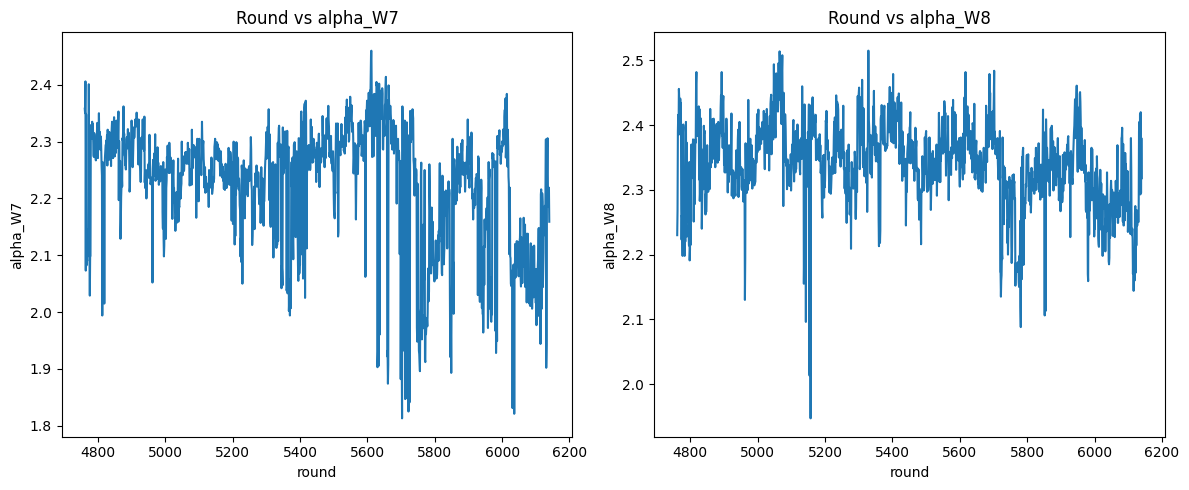

In [4]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12,5), sharex=True)

# left plot
ax[0].plot(df["round"], df["alpha_w7"])
ax[0].set_title("Round vs alpha_W7")
ax[0].set_xlabel("round")
ax[0].set_ylabel("alpha_W7")

# right plot
ax[1].plot(df["round"], df["alpha_w8"])
ax[1].set_title("Round vs alpha_W8")
ax[1].set_xlabel("round")
ax[1].set_ylabel("alpha_W8")

plt.tight_layout()
plt.show()
